# 00 — Sound, Loudness & the Vocabulary Every Script Uses

### Why this notebook exists

Every Python script in this project (`vocal_prominence.py`, `separation_quality_audit.py`, `reverb_decay_analysis.py`...) leans on a small handful of ideas: **waveform**, **sample rate**, **RMS**, **decibels (dB)**. If those words are still a fog, the scripts read like a foreign language — which is exactly what you told us after Labs 1-4.

This notebook is **not** a general audio-engineering textbook chapter. It only covers the vocabulary you actually needed in the labs so far, and every idea is tested immediately against the real tracks in this project:

- **Elissa — "Maktouba Leek"** → our professional, human-mixed reference track.
- **"Ya Dar Maya" (Suno original) and its `SONG_A` cover** → our AI-generated test tracks.

By the end, you will be able to look at a line like `rms_db(y)` in any script here and know exactly what it computes and why.

> **How you'll verify each idea:** for every concept, you'll listen to (or look at) something concrete from the repo and check that the number the code produces matches what you actually hear or see. Numbers serve your ears, not the other way around (per `AGENTS.md`).


## Setup

We only use packages already installed in this project's environment: `librosa` (loading + audio analysis), `numpy` (math), `matplotlib` (plots), and `IPython.display.Audio` (so you can actually press play on a clip *inside* the notebook — this is the biggest advantage of Jupyter for this kind of learning).


In [1]:
import numpy as np
import librosa
import matplotlib.pyplot as plt
from IPython.display import Audio, display

# Paths to the real project audio (relative to notebooks/, so we go one level up)
DATA_DIR = "../data"

ELISSA_MIX  = f"{DATA_DIR}/elisa_maktooba_leek.mp3"
SONGA_MIX   = f"{DATA_DIR}/يا دار مية - 28-07-2026_SONG_A.mp3"

print("Files exist:")
import os
for p in [ELISSA_MIX, SONGA_MIX]:
    print(" ", p, "->", os.path.exists(p))


Files exist:
  ../data/elisa_maktooba_leek.mp3 -> True
  ../data/يا دار مية - 28-07-2026_SONG_A.mp3 -> True


## A. What *is* a sound wave? (amplitude vs. time)

A microphone (or, for Suno, a generative model) does one simple thing: it records **how far the air pressure pushed at every tiny instant of time**. That single number — "how far pushed, right now" — is called **amplitude**. A digital audio file is just a very long list of these amplitude numbers, one after another, in time order.

- **x-axis** = time (seconds)
- **y-axis** = amplitude (roughly −1.0 to +1.0 for a normalized digital file — 0 is silence, further from 0 is louder)

That's it. Every waveform plot you'll see in this project's scripts (and every plot below) is just this list of numbers, zoomed in or out.

Let's load 3 seconds of Elissa's real mix and look at the raw wave.


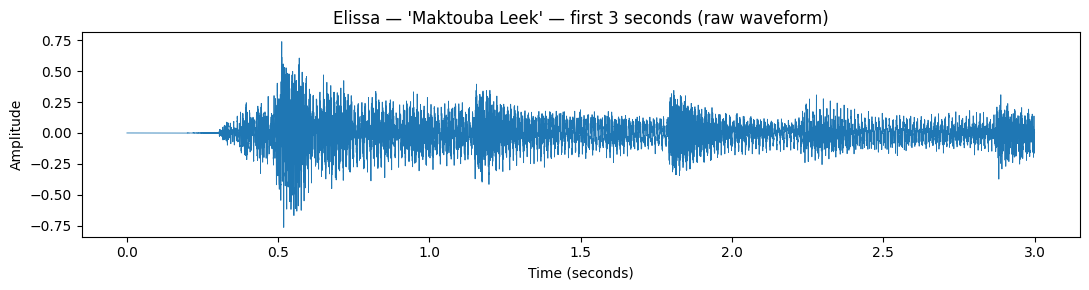

Listen to the exact 3 seconds you just plotted:


In [2]:
# Load only the first 3 seconds - librosa can do this directly with `duration=`
y_elissa, sr_elissa = librosa.load(ELISSA_MIX, sr=None, mono=True, duration=3.0)

t = np.linspace(0, len(y_elissa) / sr_elissa, num=len(y_elissa))

plt.figure(figsize=(11, 3))
plt.plot(t, y_elissa, linewidth=0.6)
plt.title("Elissa — 'Maktouba Leek' — first 3 seconds (raw waveform)")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.tight_layout()
plt.show()

print("Listen to the exact 3 seconds you just plotted:")
display(Audio(y_elissa, rate=sr_elissa))


**Look at the plot, then press play above.** Notice the loud opening hit lines up with the tallest spike in the wave, and any quiet moment lines up with the wave flattening near zero. That correspondence — *taller wave = louder sound, at that instant* — is the entire idea behind every "loudness" measurement in this project.


## B. Sample rate: how often do we take a snapshot?

A computer can't store a truly continuous wave — it takes **snapshots** (samples) of the amplitude many times per second. The **sample rate (`sr`)** is just: *how many snapshots per second*.

- 44,100 Hz ("44.1kHz", CD quality) = 44,100 snapshots every second.
- 48,000 Hz ("48kHz", common in video/streaming) = 48,000 snapshots every second.

**Why `librosa.load(path, sr=None)` matters:** by default, `librosa.load()` silently **resamples everything to 22,050 Hz** unless you tell it `sr=None` ("keep the file's own original rate"). Every script in this project uses `sr=None` deliberately, so it never throws away audio detail or (worse) mixes tracks that were originally recorded at different rates without knowing it.

Let's prove the two project tracks actually **do** have different native sample rates — this is exactly the kind of thing that silently breaks an analysis if you don't check it.


In [3]:
# Compare native sample rates of the two tracks — load just 1 second each, we only need the header/sr info
_, sr_elissa_native = librosa.load(ELISSA_MIX, sr=None, duration=1.0)
_, sr_songa_native  = librosa.load(SONGA_MIX,  sr=None, duration=1.0)

print(f"Elissa native sample rate : {sr_elissa_native} Hz")
print(f"SONG_A native sample rate : {sr_songa_native} Hz")

if sr_elissa_native != sr_songa_native:
    print("\n-> Confirmed: these two tracks were exported at DIFFERENT sample rates.")
    print("   If a script ever compares them sample-by-sample without resampling first,")
    print("   it would be silently comparing the wrong instants in time.")


Elissa native sample rate : 44100 Hz
SONG_A native sample rate : 48000 Hz

-> Confirmed: these two tracks were exported at DIFFERENT sample rates.
   If a script ever compares them sample-by-sample without resampling first,
   it would be silently comparing the wrong instants in time.


**Take-away:** `sr` is not a technicality to skip past — Elissa and the Suno tracks in this project genuinely use different native rates (44.1kHz vs 48kHz). Any script that loads two tracks and treats "sample number 1000" as "the same moment in both" without checking `sr` first is already wrong. That's why you'll see `sr=None` everywhere in this repo's scripts, and why some scripts explicitly resample before comparing tracks.


## C. RMS and dB — turning a wave into a single "loudness" number

A raw waveform has *thousands* of amplitude numbers per second — too many to compare directly ("was Elissa's vocal louder than SONG_A's vocal?"). We need one number that summarizes loudness over a stretch of time.

### Step 1 — RMS (Root Mean Square)

RMS answers: *"on average, how much energy did this chunk of audio have?"* We can't just average the raw amplitudes (positive and negative values cancel out to ~0). Instead RMS:

1. **Squares** every amplitude value (removes negative signs, and emphasizes loud peaks more than quiet ones — closer to how energy/power actually works).
2. Takes the **mean** of those squared values.
3. Takes the **square root** to bring the units back to a comparable scale.

$$\text{RMS} = \sqrt{\frac{1}{N}\sum_{i=1}^{N} x_i^2}$$

### Step 2 — why convert RMS to decibels (dB)?

Human hearing is **not linear** — it's closer to *logarithmic*. Doubling the physical energy of a sound does **not** make it sound twice as loud to your ear; it takes a *much* bigger jump in raw energy before your ear perceives "twice as loud." dB compresses RMS onto a scale that matches how your ear actually experiences loudness differences — this is why every finding in `context.md` is expressed in dB ("+3.33 dB", "13.55 dB std"), never in raw RMS numbers.

$$\text{dB} = 20 \cdot \log_{10}(\text{RMS})$$

(RMS values are between 0 and 1, so this formula gives **negative** dB numbers — 0 dB = the loudest a digital file can be without clipping, and more negative = quieter. This matches the `rms_db()` used across this project's scripts.)


In [4]:
def rms_db(y, eps=1e-10):
    '''
    Convert an audio signal (numpy array) into a single loudness number in dB.
    This is the same function used throughout this project's scripts
    (vocal_prominence.py, separation_quality_audit.py, etc.).

    eps: a tiny number added before the log, so a perfectly silent (all-zero)
         signal doesn't crash with log(0) = -infinity.
    '''
    rms = np.sqrt(np.mean(y ** 2))
    return 20 * np.log10(rms + eps)


# Sanity check: a louder signal should give a HIGHER (less negative) dB value
quiet_signal = np.array([0.01, -0.01, 0.01, -0.01])
loud_signal  = np.array([0.5,  -0.5,  0.5,  -0.5])

print(f"Quiet signal -> {rms_db(quiet_signal):.2f} dB")
print(f"Loud signal  -> {rms_db(loud_signal):.2f} dB")
print("\nLouder signal has a HIGHER dB number (less negative) - as expected.")


Quiet signal -> -40.00 dB
Loud signal  -> -6.02 dB

Louder signal has a HIGHER dB number (less negative) - as expected.


### Now apply `rms_db()` to real project audio

Let's measure the overall loudness of the full Elissa mix vs. the full SONG_A mix, and — most importantly — **listen to short clips from each** so you can check the dB numbers against your own ears.


In [5]:
# Load full tracks at their own native sample rate (this takes a few seconds - real files, several minutes long)
y_elissa_full, sr_e = librosa.load(ELISSA_MIX, sr=None, mono=True)
y_songa_full,  sr_a = librosa.load(SONGA_MIX,  sr=None, mono=True)

elissa_loudness = rms_db(y_elissa_full)
songa_loudness  = rms_db(y_songa_full)

print(f"Elissa 'Maktouba Leek' overall loudness : {elissa_loudness:.2f} dB  (duration: {len(y_elissa_full)/sr_e:.1f}s)")
print(f"SONG_A overall loudness                 : {songa_loudness:.2f} dB  (duration: {len(y_songa_full)/sr_a:.1f}s)")
print(f"\nDifference: {abs(elissa_loudness - songa_loudness):.2f} dB")


Elissa 'Maktouba Leek' overall loudness : -10.90 dB  (duration: 317.0s)
SONG_A overall loudness                 : -15.90 dB  (duration: 269.7s)

Difference: 5.01 dB


In [6]:
# Listen to a matched 5-second window from roughly the middle of each track, so you can compare by ear
def middle_clip(y, sr, seconds=5.0):
    start = len(y) // 2
    end = start + int(seconds * sr)
    return y[start:end]

elissa_clip = middle_clip(y_elissa_full, sr_e)
songa_clip  = middle_clip(y_songa_full,  sr_a)

print(f"Elissa clip loudness : {rms_db(elissa_clip):.2f} dB")
display(Audio(elissa_clip, rate=sr_e))

print(f"SONG_A clip loudness : {rms_db(songa_clip):.2f} dB")
display(Audio(songa_clip, rate=sr_a))


Elissa clip loudness : -11.88 dB


SONG_A clip loudness : -16.19 dB


**How to verify this yourself:** play both clips back to back. The one with the higher (less negative) dB number printed above should be the one that sounds subjectively louder to you overall. If it doesn't match, that's actually an important, valid observation — dB (RMS-based) measures *average energy*, not perceived loudness in every nuance (e.g. a track that is loud but very repetitive vs. one with quiet verses and loud choruses can have the same average dB but feel different). Keep this caveat in mind — it becomes relevant again in later notebooks (Notebook 02 is *entirely* about a case where "the average number lied").


## D. Instrument sound vs. human voice — the basic difference (concept only)

You'll see this distinction come up constantly (vocal stem vs. instrumental stem). Here is the beginner-level concept — full frequency analysis is coming in **Notebook 03**, so we keep this section light and visual only.

- Every musical note (sung or played) is not really "one pure tone." It's a **fundamental frequency** (the main pitch you perceive) plus a stack of quieter **harmonics** (multiples of that fundamental) on top of it.
- What makes a human voice sound like a *voice*, and not like a violin playing the exact same pitch, is mostly the **formants** — resonances shaped by the size/shape of the mouth, throat, and nasal cavity as we speak/sing. Instruments have their own equivalent resonances (the body of a guitar, the bore of a trumpet), just shaped by wood/metal instead of a vocal tract.
- **You don't need the math of this yet.** The one practical consequence for this project: a human voice's formants shift constantly (we're moving our mouth as we sing words), which is part of *why* vocals are trickier for AI separation models to cleanly isolate than a more static instrument tone — a thread you'll pick up again in Notebook 04 (auditing separation quality).

Let's just *look* at the difference in raw waveform shape between a sustained vocal moment and a sustained instrumental moment, using this project's real AI-separated stems.


Vocal window starts at   56.5s (chosen as an actively-singing moment)
Instrumental window starts at 173.0s (chosen as an actively-playing moment)


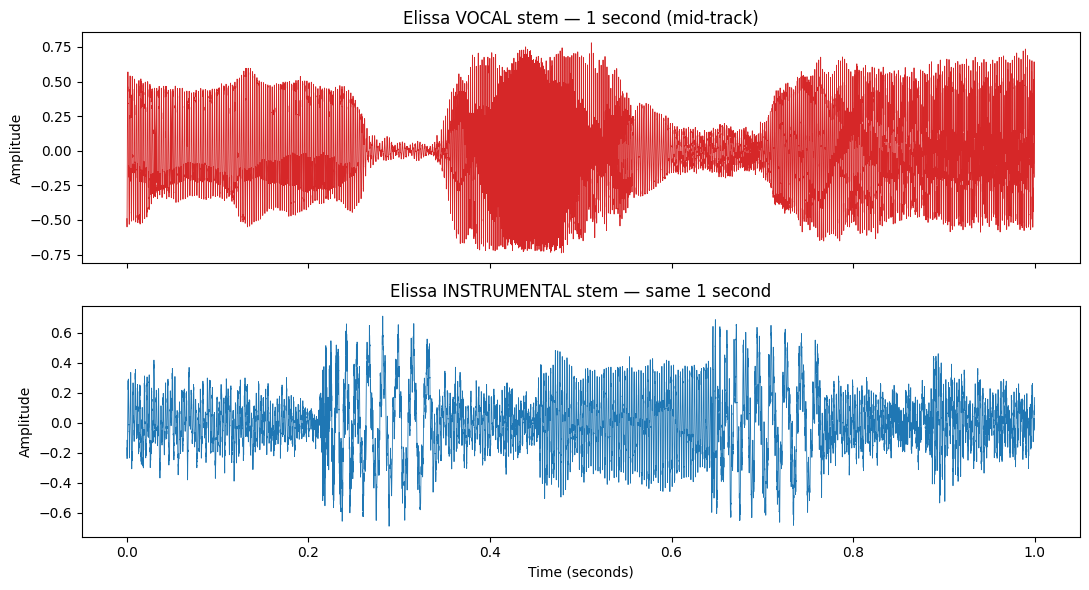

Vocal stem, this window:


Instrumental stem, this window:


In [7]:
VOCALS_STEM       = f"{DATA_DIR}/elisa_maktooba_leek/elisa_maktooba_leek-Vocals.mp3"
INSTRUMENTAL_STEM = f"{DATA_DIR}/elisa_maktooba_leek/elisa_maktooba_leek-Instrumental.mp3"

y_vocals, sr_v = librosa.load(VOCALS_STEM, sr=None, mono=True)
y_instr,  sr_i = librosa.load(INSTRUMENTAL_STEM, sr=None, mono=True)


def loudest_window(y, sr, window_seconds=1.0, hop_seconds=0.5):
    """Slide a window across y and return the start sample of whichever window has the
    highest RMS. We use this instead of just grabbing the exact middle of the track,
    because - as you'll see in Notebook 04 - a real known fact about this project's vocal
    stems is that a large fraction of their frames are literal digital silence (a
    'hard gate' artifact from the AI separation step). Landing on one of those by
    chance would give us a flat, silent line to look at instead of an actual vocal.
    """
    win = int(window_seconds * sr)
    hop = int(hop_seconds * sr)
    best_start, best_rms = 0, -1.0
    for start in range(0, len(y) - win, hop):
        seg = y[start:start + win]
        r = np.sqrt(np.mean(seg ** 2))
        if r > best_rms:
            best_rms = r
            best_start = start
    return best_start


start_v = loudest_window(y_vocals, sr_v)
start_i = loudest_window(y_instr, sr_i)

window_v = y_vocals[start_v:start_v + int(1.0 * sr_v)]     # 1 second, zoomed for shape detail
window_i = y_instr[start_i:start_i + int(1.0 * sr_i)]

print(f"Vocal window starts at   {start_v/sr_v:.1f}s (chosen as an actively-singing moment)")
print(f"Instrumental window starts at {start_i/sr_i:.1f}s (chosen as an actively-playing moment)")

fig, axes = plt.subplots(2, 1, figsize=(11, 6), sharex=True)
axes[0].plot(np.linspace(0, 1, len(window_v)), window_v, linewidth=0.6, color="tab:red")
axes[0].set_title("Elissa VOCAL stem — 1 second (mid-track)")
axes[0].set_ylabel("Amplitude")

axes[1].plot(np.linspace(0, 1, len(window_i)), window_i, linewidth=0.6, color="tab:blue")
axes[1].set_title("Elissa INSTRUMENTAL stem — same 1 second")
axes[1].set_xlabel("Time (seconds)")
axes[1].set_ylabel("Amplitude")

plt.tight_layout()
plt.show()

print("Vocal stem, this window:")
display(Audio(window_v, rate=sr_v))
print("Instrumental stem, this window:")
display(Audio(window_i, rate=sr_i))


You may have noticed the code above specifically searched for the *loudest* one-second window instead of just grabbing the middle of the track — a plain middle-of-track window for the vocal stem happens to land on total silence here. That is not a bug in our code; it is a real, documented property of this project's AI-separated vocal stems (a "hard gate" — see `context.md`, Section 3) that you'll examine properly in Notebook 04.

Notice the instrumental wave often looks more **regular/repetitive** (steady instruments sustaining notes or a steady rhythm section), while the vocal wave tends to look more **irregular/varying** shape-to-shape — that visual "messiness" is a rough proxy for the constantly-shifting formants of a singing voice. We are *not* trying to prove anything rigorous here yet — just building intuition before Notebook 03 gives you the real frequency-domain tool (the spectrogram) to see this properly.


## Self-Check

Try to answer each question yourself (out loud or on paper) *before* expanding the answer. If you get one wrong, re-read that section — don't just move on.

<details>
<summary><b>Q1.</b> Looking at a waveform plot, what does the y-axis (amplitude) actually represent, physically?</summary>

**A1.** It represents how far the air pressure was pushed at that instant (roughly, how far the microphone diaphragm/speaker cone moved). It is *not* frequency and it is *not* directly "loudness in dB" — it's the raw instantaneous pressure value, positive or negative.
</details>

<details>
<summary><b>Q2.</b> Why does this project always load audio with <code>librosa.load(path, sr=None)</code> instead of the librosa default?</summary>

**A2.** The default silently resamples every file down to 22,050 Hz, which can throw away detail and — more importantly — this project's own tracks have genuinely different native sample rates (Elissa: 44,100 Hz vs. Ya Dar Maya/SONG_A: 48,000 Hz). Using `sr=None` keeps each file's true original rate so comparisons stay honest and controlled.
</details>

<details>
<summary><b>Q3.</b> If Track X measures −20 dB and Track Y measures −14 dB using <code>rms_db()</code>, which one has more average energy, and roughly how should that sound to your ear?</summary>

**A3.** Track Y (−14 dB) has more average energy — it's the higher (less negative) number. It should sound noticeably louder overall to your ear when played at the same volume setting, since dB was specifically built to track how your ear perceives loudness differences (unlike raw RMS or raw amplitude).
</details>

<details>
<summary><b>Q4.</b> Why do we square the amplitude values before averaging, in the RMS formula, instead of just averaging the raw amplitudes directly?</summary>

**A4.** Raw amplitude values are positive and negative in roughly equal measure (the wave goes above and below zero), so a plain average would land near zero regardless of how "loud" the signal actually is. Squaring removes the sign (so peaks don't cancel out) and better reflects energy, which is proportional to amplitude squared in physics.
</details>

<details>
<summary><b>Q5.</b> What is a formant, in plain language, and why does it matter for telling a human voice apart from an instrument playing the same note?</summary>

**A5.** A formant is a resonance — a frequency range that gets boosted — shaped by the physical cavity the sound travels through (mouth/throat/nasal passages for a voice; the body/bore of an instrument). Formants (and how they shift as we speak/sing) are a big part of what makes a voice sound like a *voice* rather than an instrument playing an identical pitch, and they're part of why vocals are harder to cleanly separate with AI than more static instrument tones.
</details>


## Summary — what you now have

- **Waveform** = amplitude (air pressure push) plotted against time. Nothing more mysterious than that.
- **Sample rate (`sr`)** = how many amplitude snapshots per second. This project's tracks genuinely differ (44.1kHz vs 48kHz) — always load with `sr=None` and check it, don't assume.
- **RMS** = a single "average energy" number for a chunk of audio (square, mean, square-root).
- **dB** = RMS converted onto a logarithmic scale so numbers actually track what your ear perceives as louder/quieter. Every finding in `context.md` is reported in dB for this reason.
- **Instrument vs. voice (conceptual preview):** both are a fundamental pitch + harmonics; a voice's constantly-shifting formants are a big part of what makes it sound distinctly "vocal," and part of why voices are harder for AI separation to isolate cleanly.

### What's next

**Notebook 01 — The Stereo Field & Our First (Flawed) Hypothesis** will pick up right where this project's real Lab 1 started: what "Mid/Side" stereo decomposition is, why the team first believed it could estimate vocal prominence without needing real separated stems, and how that first hypothesis got "confirmed" — a little too fast.

*(Per the phased execution protocol, this session stops here. Notebook 01 will only be started after you review and confirm this one.)*
